# CDMX Metro Hill-Climbing Implementation

In this exercise Hill-Climbing search mode will be implemented using the case of CDMX Metro system. To give context about it, CDMX Metro System is the subway system formed by 12 lines and 163 stations, which many of them share connections between lines.

The goal of this exercise is to find the shortest path between two stations using Hill-Climbing method considering no backward steps and no memory.

# Table of contents

- [Packages and Custom libraries import](#package-and-custom-libraries-imports)
- [CDMX Metro Graph Definition](#cdmx-metro-graph-definition)
- [Hill-Climbing Search Implementation](#hill-climbing-search-implementation)

# Package and Custom Libraries Imports

The following packages and custom libraries serve to 

- Load the metro system json catalogs and build the main graph
- Define the problem as graph problem
- Draw the graph using coordinates and colors to make it similar to the actual CDMX metro system
- Import the search functions from the script

Also the following imports will set root to `Sistemas-Inteligentes/`

In [1]:
import sys
import os
import json
from dotenv import load_dotenv
import os

# Get the main route of the proyect
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add to path
sys.path.append(PROJECT_ROOT)

# Import the .env file (not uploaded to the repo)
ENV_PATH = os.path.join(PROJECT_ROOT, ".env")

load_dotenv(ENV_PATH)

API_KEY = os.getenv("GOOGLE_MAPS_API_KEY")

print("Project root added:", PROJECT_ROOT)

# Imports to build the main graph
# get_station_coords is in the list but won't be used expicitly since we have already the coords
from src.catalog_loader import load_metro_graph
from src.CDMX_metro_weighted_graph import build_weighted_graph, get_station_coords, straight_line_distance
from src.helper_funcs import preview

# Imports for graph visualization
from src.graphDrawer import build_graph, build_geo_layout, draw_metro_graph

# Imports to implement an informed search
from src.graphProblem import GraphProblem
from src.search_algorithms import hill_climbing

Project root added: C:\Users\odver\OneDrive\Documentos\MAC-Ayrton94\2026-2\git\MAC-Ayrton94\Sistemas-Inteligentes


# CDMX Metro Graph Definition

The graph is designed to show all connections between metro stations. However it must be built for it to be used. The graph is splitted in 12 JSON files in the `metro/` directory. Each file has two keys, `color` which is the color of the metro line and `network` which is a dictionary that contains a series of dictionaries that follow the structure

```json
{
    "station_name": {"previous_station_name": 1, "next_station_name": 1}
}
```

we set the weight value to 1 as default since it is going to be overwritten once we connect to the Google Maps API through the build_weighted_graph

In [2]:
# First we load the main graph
metro_graph = load_metro_graph(folder="../metro")
node_colors = metro_graph[1]
print("Preview, first 5 keys")
preview(metro_graph[0])

163 stations were uploaded from '../metro' directory.
Preview, first 5 keys


{'Observatorio': "{'Tacubaya': 1}",
 'Tacubaya': "{'Observatorio': 1, 'Juanacatlán': 1, 'Constituyentes': 1, 'San Pedro de los Pin...",
 'Juanacatlán': "{'Tacubaya': 1, 'Chapultepec': 1}",
 'Chapultepec': "{'Juanacatlán': 1, 'Sevilla': 1}",
 'Sevilla': "{'Chapultepec': 1, 'Insurgentes': 1}"}

In [3]:
# Then we have to overwrite the weights using real distances provided by Google Maps API
# Run the following code to generate the weighted graph
# weighted_graph = build_weighted_graph(API_KEY, metro_graph[0])

# Otherwise if you already have it stored physically in JSON format
with open("../output/CDMX_metro_weighted.json", "r", encoding="utf-8") as f:
    weighted_graph = json.load(f)

print("Preview, first 5 keys")
preview(weighted_graph)

Preview, first 5 keys


{'Observatorio': "{'Tacubaya': 2942}",
 'Tacubaya': "{'Observatorio': 2942, 'Juanacatlán': 1579, 'Constituyentes': 1427, 'San Pedro d...",
 'Juanacatlán': "{'Tacubaya': 1579, 'Chapultepec': 1939}",
 'Chapultepec': "{'Juanacatlán': 1939, 'Sevilla': 1087}",
 'Sevilla': "{'Chapultepec': 1087, 'Insurgentes': 947}"}

In [4]:
# To generate the coordinates for the first time
# metro_coords = get_station_coords(weighted_graph, API_KEY)

# with open("../output/CDMX_metro_coords.json", "w", encoding="utf-8") as f:
#     json.dump(metro_coords, f, indent=4, ensure_ascii=False)

# To read if it was already generated
with open("../output/CDMX_metro_coords.json", "r", encoding="utf-8") as f:
    metro_coords = json.load(f)

print("Preview, first 5 keys")
preview(metro_coords)

Preview, first 5 keys


{'Observatorio': '[19.39828, -99.2004]',
 'Tacubaya': '[19.401932, -99.187355]',
 'Juanacatlán': '[19.4128272, -99.18181229999999]',
 'Chapultepec': '[19.420899, -99.1755634]',
 'Sevilla': '[19.421501, -99.1710272]'}

✔ Imagen generada en: ../output/grafo_metro.png


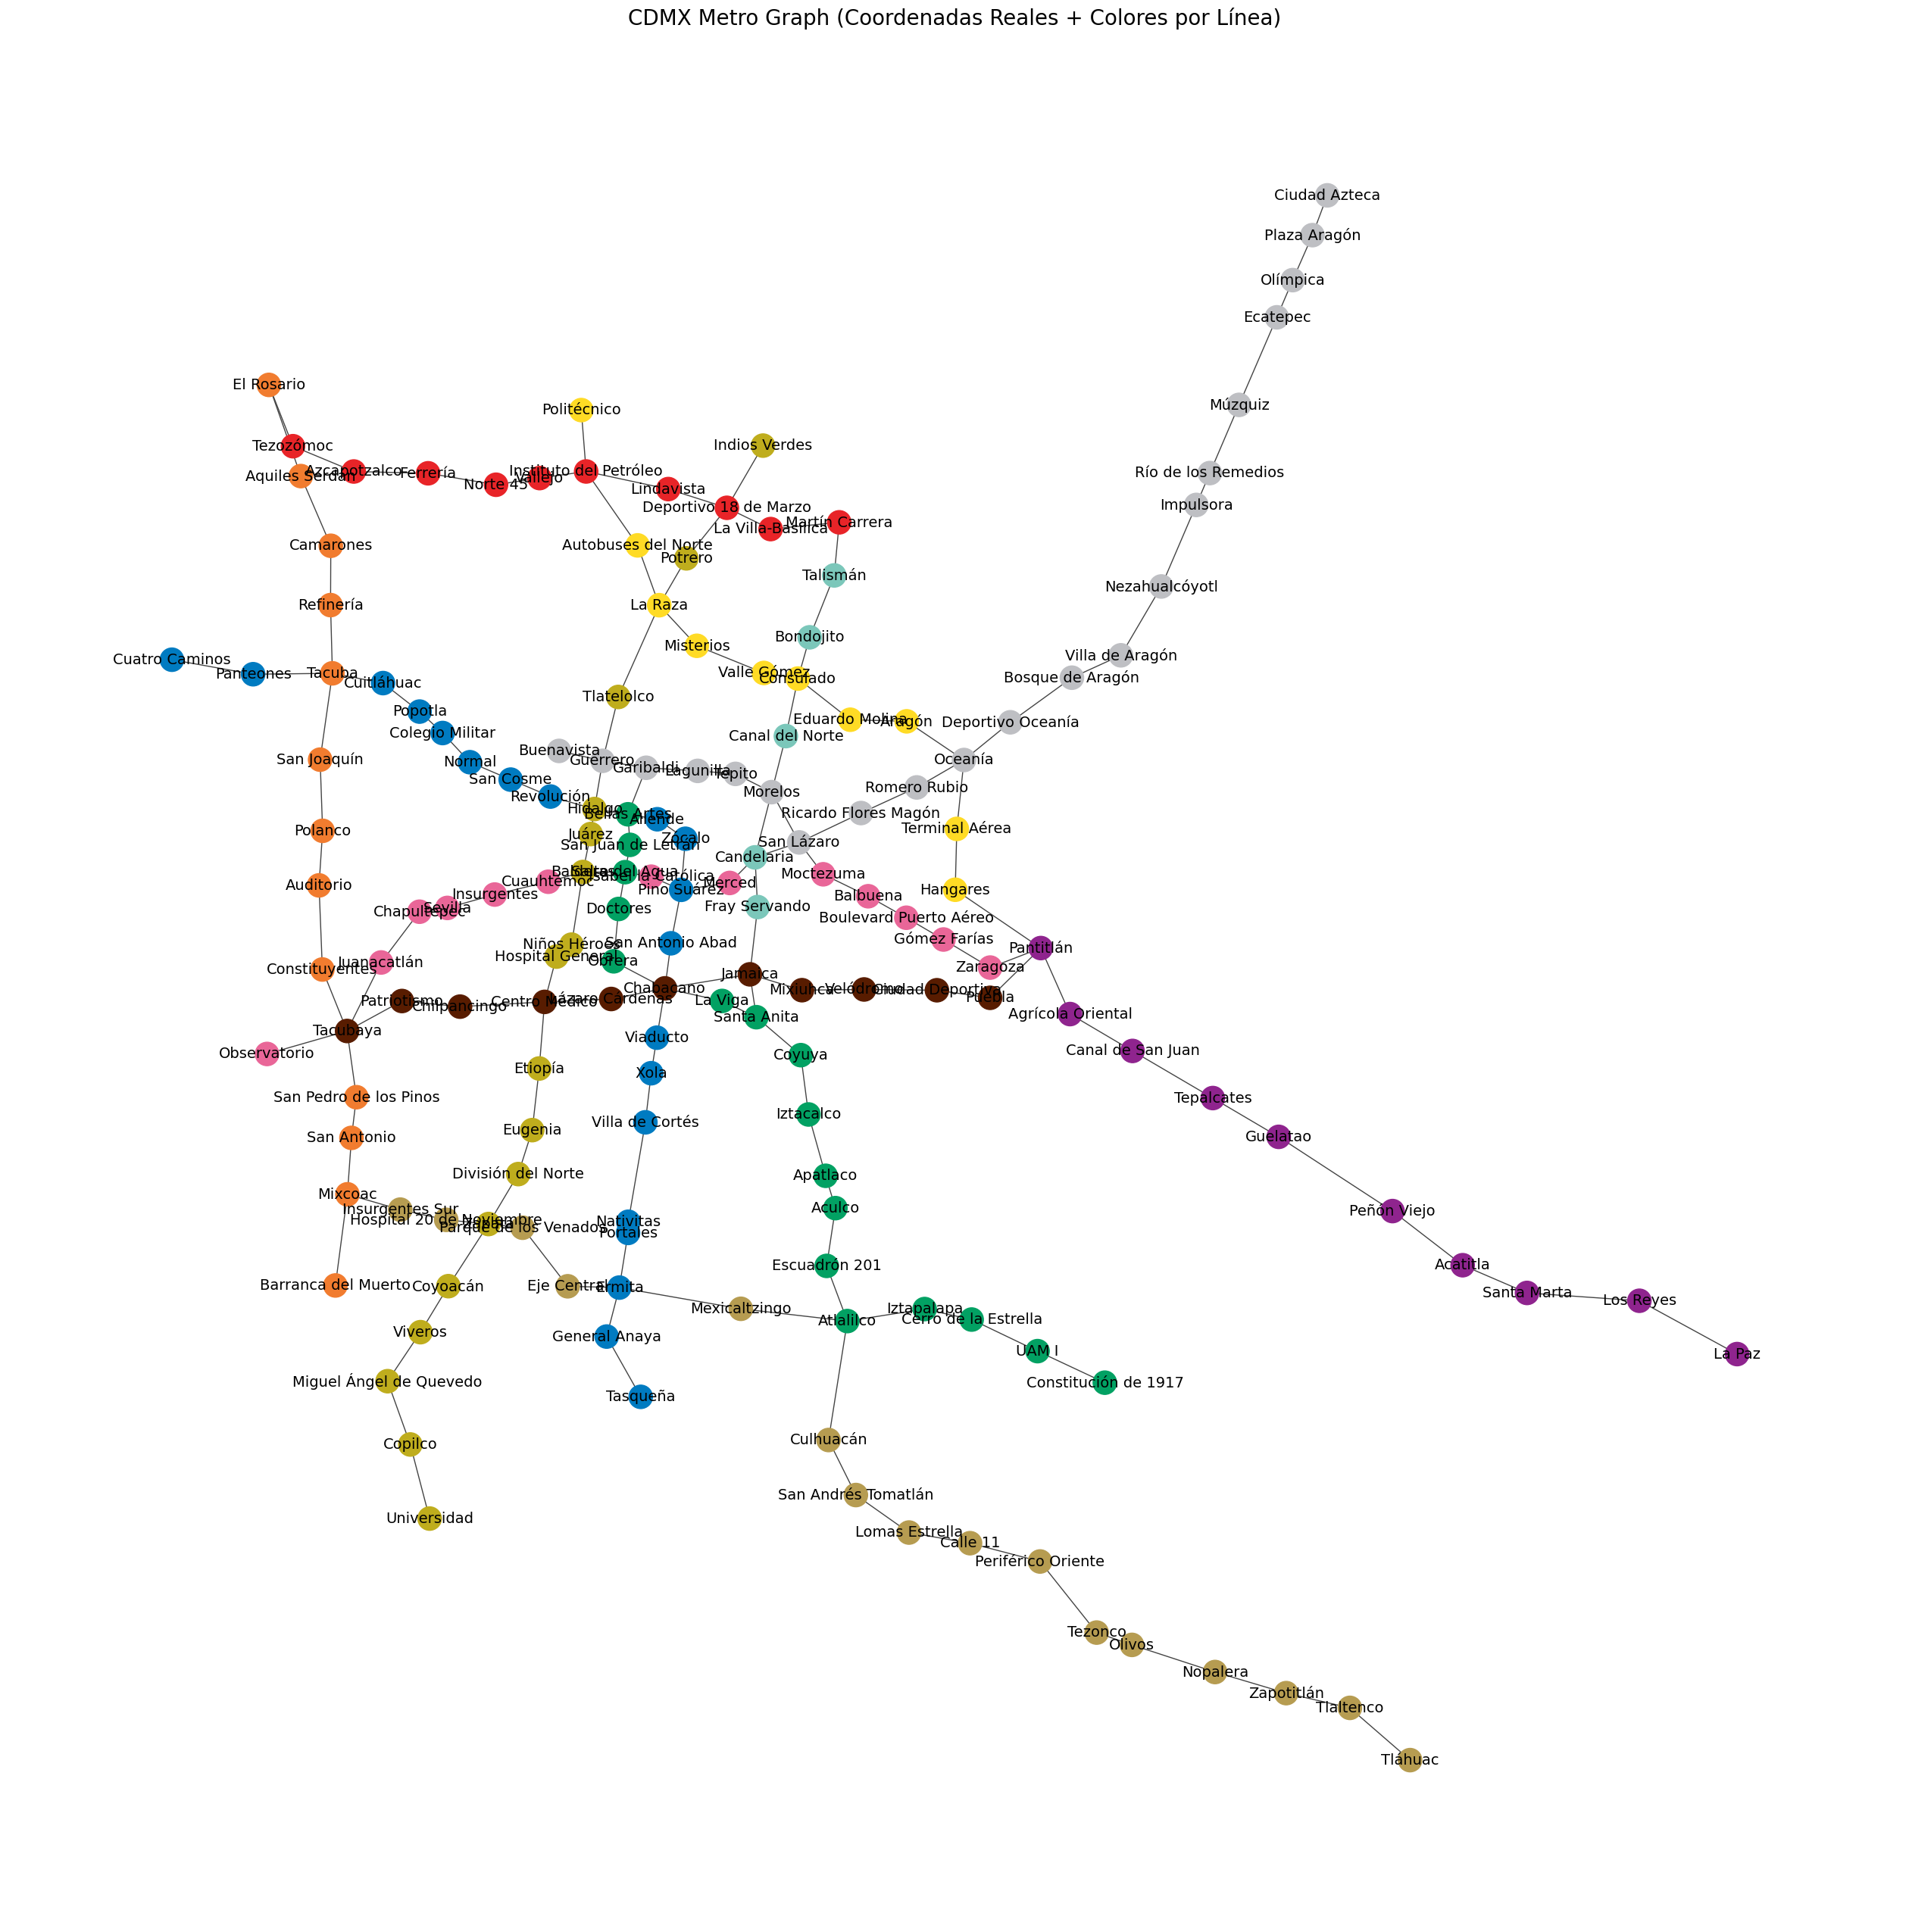

In [5]:
# To visualize the graph
G, node_colors = build_graph(weighted_graph, node_colors)
pos = build_geo_layout(metro_coords)
draw_metro_graph(G, pos, node_colors, output_path="../output/grafo_metro.png")

# Hill-Climbing Search Implementation

Hill-Climbing in contrast of A* is a method that only uses heuristic to choose a path. This can be comparable to greedy best-first. However the difference is in how the heuristic is observed. In Greedy Best-First the decision to advance depends only in the value of the heuristic for child nodes, in other words a path will record a step to the node with $h=\min{h}$. On the other hand, Hill-Climbing advances only if there is an improvement in the heuristic, which means if $h(current-node)>\min{(h(child-nodes))}$ making an informed search looking at only the immediate neighbors and taking the decision whether the heuristic improves or not

For this algorithm we are going to search the path from Cuatro Caminos station to Pantitlán, Politécnico to Taxqueña and finally Zapata to Oceanía (Not Deportivo Oceanía).

First we will calculate the heuristic tables related to them. To this end we already have a station coordinates we already used to order the graph.

In [6]:
# Calculation of straight line distance to given target stations
stations = ["Pantitlán", "Tasqueña", "Oceanía"]
straight_lines = list()

for target_station in stations:
    try:
        with open(f"../output/CDMX_{target_station}_straight_line_haversine.json", "r", encoding="utf-8") as f:
            straight_line = json.load(f)
    except:
        straight_line = straight_line_distance(target_station=target_station, coords=metro_coords, method="haversine")
        with open(f"../output/CDMX_{target_station}_straight_line_haversine.json", "w", encoding="utf-8") as f:
            json.dump(straight_line, f, indent=4, ensure_ascii=False)
    straight_lines.append(straight_line)
    print("Printing preview: ", preview(straight_line))    

Printing preview:  {'Observatorio': '14018.050953953145', 'Tacubaya': '12566.513859127343', 'Juanacatlán': '11948.107791391114', 'Chapultepec': '11253.65508035555', 'Sevilla': '10749.379932516667'}
Printing preview:  {'Observatorio': '6837.03801281103', 'Tacubaya': '5416.746615207564', 'Juanacatlán': '4857.956860049264', 'Chapultepec': '4232.893752502982', 'Sevilla': '3762.721475957395'}
Printing preview:  {'Observatorio': '12650.946343937923', 'Tacubaya': '11199.294728551304', 'Juanacatlán': '10572.385257862823', 'Chapultepec': '9871.436771160053', 'Sevilla': '9367.047523680862'}


In [7]:
# First we will see the path to Metro Cuatro Caminos to Metro Pantitlán
problem1 = GraphProblem(initial="Cuatro Caminos", goal="Pantitlán", graph=weighted_graph, heuristic_table=straight_lines[0])
node = hill_climbing(problem1)
node.pretty_path()

Cuatro Caminos → Panteones → Tacuba → Cuitláhuac → Popotla → Colegio Militar → Normal → San Cosme → Revolución → Hidalgo → Bellas Artes → Allende → Zócalo
Total Cost: 10831 meters


We can notice that, in this case the method found a dead end and decided to not advance more

In [9]:
print(f"Zócalo: {straight_lines[0].get("Zócalo")}\nPino Suárez: {straight_lines[0].get("Pino Suárez")}")

Zócalo: 6444.222074550311
Pino Suárez: 6515.725222569368


Looking at the heuristic we notice that indeed, the heuristic doesn't improve from Zócalo to Pino Suárez, then the algorithm takes the decision to not advance

In [10]:
# Then we will see the path to Metro Politécnico to Metro Tasqueña
problem2 = GraphProblem(initial="Politécnico", goal="Tasqueña", graph=weighted_graph, heuristic_table=straight_lines[1])
node = hill_climbing(problem2)
node.pretty_path()

Politécnico → Instituto del Petróleo → Autobuses del Norte → La Raza → Tlatelolco → Guerrero → Garibaldi → Bellas Artes → San Juan de Letrán → Salto del Agua → Doctores → Obrera → Chabacano → Viaducto → Xola → Villa de Cortés → Nativitas → Portales → Ermita
Total Cost: 47838 meters


In [11]:
print(f"Ermita: {straight_lines[0].get("Ermita")}\nGeneral Anaya: {straight_lines[0].get("General Anaya")}")

Ermita: 7692.279392538106
General Anaya: 7937.9389630517635


This was a weird result, but totally understandable considering the coordinates and how the heuristic is used, because is calculating the distance between th two points in straight line, and Metro General Anaya is quite far from Tasqueña compared to Ermita

In [12]:
# Finally we will see the path to Metro Zapata to Metro Oceanía
problem3 = GraphProblem(initial="Zapata", goal="Oceanía", graph=weighted_graph, heuristic_table=straight_lines[2])
node = hill_climbing(problem3)
node.pretty_path()

Zapata → Parque de los Venados → Eje Central → Ermita → Mexicaltzingo → Atlalilco → Iztapalapa → Cerro de la Estrella
Total Cost: 9187 meters


As a conclusion we can state that, when the graph possess some sort of direction Hill-Climbing is a good option, however if the graph problem is more complex, which means it has multiple connections, loops, etc. it will be easily lost.

Therefore we conclude that A* is the best approach for this problem, however we must enhance the heuristic so we can have an optimal result.